# Эксперимент 3: обучаемая GAT-политика правок маршрутов (GNN + RL поверх SUE)

**Курсовая: «Моделирование маршрутов общественного транспорта … (пригороды Санкт-Петербурга)»**

## Лестница экспериментов и место этого шага
1. Жадный бейзлайн (Pattnaik) → 2. Генетический алгоритм → 3. Bi-level **SUE** (поведение
пассажиров) → **4. (этот ноутбук) обучаемая GAT-политика точечных правок маршрутов.**

Все прошлые методы искали **внутри пула** из 39 заранее сгенерированных маршрутов-кандидатов
(k-кратчайшие пути + существующие). Их давнее ограничение — «нельзя изобрести маршрут вне
пула». Здесь мы его снимаем: графовая нейросеть (GAT), обученная через RL, предлагает
**точечные правки** уже существующей сети — заменить / вставить / удалить одну остановку в
маршруте, причём остановка берётся из графовых соседей и **может не входить ни в один маршрут
пула**. Награда — снижение `T_avg`, считается тем же симулятором `evaluate_sue` из эксперимента 3.

## Зачем именно GAT + RL (а не просто перебор)
- **Граф остановок** естественно описывается graph attention: каждая остановка «смотрит» на
  соседей по дорожной сети с весом, зависящим от времени в пути.
- **Признаки узлов берутся прямо из SUE** (стоимость остановки `C_s`, входящий поток,
  членство в текущей сети) — то есть «накопленные старые штуки» из прошлых шагов работают как
  вход для нейросети. Политика видит, *где* сеть слаба, и правит именно там.
- **RL (REINFORCE)** обучает политику предлагать улучшающие правки, не оценивая их перебором:
  она обобщает на новые сети. Литература (Holliday & Dudek 2024; Poudel & Li 2025) показывает,
  что такой подход — graph-attention backbone + RL — даёт SOTA на бенчмарках transit network
  design и хорошо работает как оператор внутри метаэвристик.

## Что проверяем (честный дизайн)
Политика обучается улучшать **случайные** (как правило плохие) сети, а оценивается на
**отложенных** случайных стартах (held-out) — так мы проверяем именно обобщение, а не
запоминание одной сети. Сравниваем три величины: старт без правок; правки обученной политики
(без «оракула» — политика применяет свой выбор вслепую); случайные правки. Дополнительно
считаем, сколько остановок **вне исходного пула** политика приводит в сеть.

> Провозимость (crowding) выключена, как и в эксперименте 3 (`crowd=False`): фокус — топология
> маршрутов; при этом `T_avg` не зависит от масштаба спроса.


## 1. Параметры
`P` — идентичны прежним ноутбуам. `GA` — гиперпараметры генетики (популяция меньше, т.к.
каждая оценка теперь дороже). `SUE` — параметры нижнего уровня (новое).

In [12]:
import json, numpy as np, pandas as pd, geopandas as gpd, networkx as nx
from shapely.geometry import LineString
from scipy.spatial import cKDTree
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
try: from IPython.display import display
except Exception: display = print

CRS = 32636

P = dict(
    walk_speed_mps   = 5*1000/3600, bus_cruise_kmh = 40, bus_speed_factor = 0.65,
    dwell_s = 29, layover_factor = 1.15,
    alpha_zan = 0.568, beta_vyezd = 0.7, gamma_ot = 0.565,
    k_shortest = 3, n_seeds = 44, max_routes = 8,
    unserved_penalty_s = 3600, peak_hours = 2.0,
    min_stops = 3, stop_dedup_m = 206,
)
P['commuter_share'] = P['alpha_zan']*P['beta_vyezd']*P['gamma_ot']   # ≈ 0.225 по модели Хаффа
P['commuter_share'] = 0.15   # скорректированная оценка доли коммьютеров на ОТ.
# ВАЖНО: при crowd=False (режим этой работы) T_avg НЕ зависит от этого числа — sqrt-правило
# раздачи парка инвариантно к масштабу спроса. commuter_share влияет лишь на иллюстративные
# абсолютные потоки/загрузки в таблицах, но не на оптимизируемую метрику.
print("commuter_share:", round(P['commuter_share'], 3))

# ── ГА (верхний уровень): меньше, т.к. фитнес теперь = равновесие ─────────────
GA = dict(pop_size=50, generations=60, elite=4, tournament=3,
          p_cross=0.85, p_mut=0.30, r_min=2, r_max=8, seed=42)

# ── SUE (нижний уровень) ─────────────────────────────────────────────────────
SUE = dict(
    theta     = 0.003,   # масштаб логита (1/сек): больше => выбор ближе к argmin
    w0        = 0.5,     # числитель ожидания: одиночный маршрут => ожидание = headway/2
    crowd_a   = 0.6,     # [опц., crowd=True] сила штрафа давки
    crowd_b   = 1.0,     # [опц., crowd=True] нелинейность штрафа по перегрузу
    crowd_cap = 2.0,     # [опц., crowd=True] потолок «избытка загрузки»
    msa_iters = 100,     # макс. итераций MSA
    msa_tol   = 1e-3,    # критерий сходимости (относительный зазор потоков)
)

def make_fleet(n_liaz, n_volga): return sorted([117]*n_liaz + [49]*n_volga, reverse=True)
FLEET = make_fleet(8, 10)
print("Парк:", len(FLEET), "машин, вместимость", sum(FLEET), "чел/рейс")

# ── ПУТИ (зеркалят бейзлайн; поправьте под свои папки) ───────────────────────
PATHS = dict(
    roads    = r"C:\Users\georg\NIS\Curse_work_2026\kud_roads_buses_v3.gpkg",
    stops    = r"C:\Users\georg\NIS\Curse_work_2026\bus_stops_v2.gpkg",
    ent      = r"C:/Users/georg/Downloads/paradniye_with_pop_v2.gpkg",
    od       = r"C:\Users\georg\NIS\od_matrix_topk.csv",
    existing = r"C:\Users\georg\Documents\kud_routes.gpkg",
    out      = r"C:\Users\georg\NIS\Curse_work_2026\gat_routes_v2.gpkg",
)

# ── torch + гиперпараметры GAT-политики и RL ─────────────────────────────────
import torch, torch.nn as nn, torch.nn.functional as F
torch.manual_seed(0)
GNN = dict(
    hidden=32, heads=4, layers=2,   # размер GAT-энкодера (граф из 44 узлов — мал, этого хватает)
    knn=6,                          # сколько графовых соседей рассматривать как кандидатов на правку
    min_len=3, max_len=12,          # границы длины маршрута при вставке/удалении
)
RL = dict(
    episodes=400, horizon=8,        # эпизодов обучения и правок в эпизоде
    gamma=0.95, lr=3e-3, seed=123,  # дисконт, шаг обучения, seed стартов
    eval_starts=8, eval_steps=10,   # held-out стартов и правок при оценке
)


commuter_share: 0.15
Парк: 18 машин, вместимость 1426 чел/рейс


## 2. Граф автобусной сети (как раньше)

In [13]:
def parse_maxspeed(v, d):
    if v is None or (isinstance(v,float) and np.isnan(v)): return d
    s=str(v)
    if s=='RU:urban': return 60
    try: return float(s.split()[0])
    except: return d

def build_bus_graph(roads_gpkg, layer='doroga_for_busiki'):
    gdf = gpd.read_file(roads_gpkg, layer=layer).to_crs(CRS).explode(index_parts=False)
    G = nx.DiGraph()
    for _, row in gdf.iterrows():
        g=row.geometry
        if g is None or g.is_empty: continue
        v = parse_maxspeed(row.get('maxspeed'), P['bus_cruise_kmh'])*P['bus_speed_factor']*1000/3600
        oneway = (row.get('oneway')=='yes'); c=list(g.coords)
        for i in range(len(c)-1):
            u=(round(c[i][0],1),round(c[i][1],1)); w=(round(c[i+1][0],1),round(c[i+1][1],1))
            if u==w: continue
            L=LineString([c[i],c[i+1]]).length
            G.add_edge(u,w,length=L,time=L/v)
            if not oneway: G.add_edge(w,u,length=L,time=L/v)
    return G.subgraph(max(nx.strongly_connected_components(G), key=len)).copy()

G = build_bus_graph(PATHS['roads'])
print("Граф:", G.number_of_nodes(), "узлов,", G.number_of_edges(), "рёбер")

Граф: 1385 узлов, 2709 рёбер


## 3. Спрос, пешие времена, маппинг stop_id голосованием (как раньше)

In [14]:
ent = gpd.read_file(PATHS['ent']).to_crs(CRS).reset_index(drop=True)
ent['entrance_id'] = ent.index + 1
ent_pop = ent.set_index('entrance_id')['population']
stops = gpd.read_file(PATHS['stops']).to_crs(CRS).reset_index(drop=True)
is_metro = stops['name'].astype(str).str.contains('Дыбенко', na=False)
board = stops[~is_metro].reset_index(drop=True)
metro = stops[is_metro].reset_index(drop=True)

od = pd.read_csv(PATHS['od'])
sxy = np.c_[board.geometry.x, board.geometry.y]; exy = np.c_[ent.geometry.x, ent.geometry.y]
_, eidx = cKDTree(sxy).query(exy, k=3)
votes = defaultdict(Counter); od_by_ent = od.groupby('entrance_id')['stop_id'].apply(list)
for eid in range(1, len(ent)+1):
    for r, sid in enumerate(od_by_ent.get(eid, [])):
        if r < 3: votes[sid][int(eidx[eid-1][r])] += 1
stopid_map = {sid: cnt.most_common(1)[0][0] for sid, cnt in votes.items()}
bad = sum(1 for _, row in od.iterrows() if row['stop_id'] in stopid_map and
          ent.iloc[row['entrance_id']-1].geometry.distance(board.iloc[stopid_map[row['stop_id']]].geometry) > row['walk_dist_m']+1)
print(f"Подъездов {len(ent)}, остановок {len(board)}, метро {len(metro)} | маппинг нарушений: {bad}")
od = od[od['stop_id'].isin(stopid_map)].copy()
od['board_idx'] = od['stop_id'].map(stopid_map)
od['t_walk'] = od['walk_dist_m'] / P['walk_speed_mps']

Подъездов 621, остановок 44, метро 7 | маппинг нарушений: 0


## 4. Времена по графу (как раньше)

In [15]:
board_nodes = [list(G.nodes)[k] for k in cKDTree(np.array(list(G.nodes))).query(np.c_[board.geometry.x, board.geometry.y])[1]]
metro_nodes = [list(G.nodes)[k] for k in cKDTree(np.array(list(G.nodes))).query(np.c_[metro.geometry.x, metro.geometry.y])[1]]
Grev = G.reverse(copy=False); dist_from_metro = {}
for mn in set(metro_nodes):
    for node, d in nx.single_source_dijkstra_path_length(Grev, mn, weight='time').items():
        if d < dist_from_metro.get(node, 1e18): dist_from_metro[node] = d
n = len(board)
t_to_metro = np.array([dist_from_metro.get(board_nodes[i], np.inf) for i in range(n)])
t_between = np.full((n, n), np.inf)
cache = {sn: nx.single_source_dijkstra_path_length(G, sn, weight='time') for sn in set(board_nodes)}
for i, bi in enumerate(board_nodes):
    for j, bj in enumerate(board_nodes): t_between[i, j] = cache[bi].get(bj, np.inf)
print(f"Остановок с временем до метро: {np.isfinite(t_to_metro).sum()}/{n}")

Остановок с временем до метро: 44/44


## 5. Пул кандидатов (k-кратчайших + существующие, с dedup — как в бейзлайне)

In [16]:
# Схлопывает соседние остановки маршрута ближе P['stop_dedup_m'] м (артефакт снэппинга).
def dedup_seq(seq):
    if not seq: return seq
    bxy = np.c_[board.geometry.x.values, board.geometry.y.values]; out=[seq[0]]
    for s in seq[1:]:
        if np.hypot(*(bxy[s]-bxy[out[-1]])) < P['stop_dedup_m']: continue
        out.append(s)
    return out

def route_oneway_time(r):
    if not r: return np.inf
    return sum(t_between[a,b] for a,b in zip(r[:-1],r[1:])) + t_to_metro[r[-1]]

demand_stop = np.zeros(len(board))
for eid, grp in od[od['rank']==1].groupby('entrance_id'):
    demand_stop[int(grp.iloc[0]['board_idx'])] += ent_pop.get(eid, 0)
btree = cKDTree(np.array(board_nodes)); target = metro_nodes[0]
seeds = sorted(range(len(board)), key=lambda i: -(demand_stop[i]*(t_to_metro[i] if np.isfinite(t_to_metro[i]) else 0)))[:P['n_seeds']]
cands = []
for s in seeds:
    try: paths = nx.shortest_simple_paths(G, board_nodes[s], target, weight='time')
    except nx.NetworkXNoPath: continue
    for k, path in enumerate(paths):
        if k >= P['k_shortest']: break
        seq, seen = [], set()
        for node in path:
            d, bi = btree.query(node, k=1)
            if d < 30 and int(bi) not in seen: seq.append(int(bi)); seen.add(int(bi))
        seq = dedup_seq(seq)
        if len(seq) >= P['min_stops']: cands.append(seq)
def load_existing():
    bt2 = cKDTree(np.c_[board.geometry.x, board.geometry.y]); out=[]
    for src, layer in [(PATHS['existing'],'existing_routes'), ('OUTPUT.gpkg','existing_routes'), ('avtobus_marshruty.gpkg','autobudd')]:
        try: er = gpd.read_file(src, layer=layer).to_crs(CRS)
        except Exception: continue
        for _, row in er.iterrows():
            g=row.geometry
            if g is None: continue
            coords=[c for gg in (g.geoms if g.geom_type=='MultiLineString' else [g]) for c in gg.coords]
            seq, seen=[], set()
            for (x,y) in coords:
                d, bi = bt2.query([x,y], k=1)
                if d<60 and int(bi) not in seen: seq.append(int(bi)); seen.add(int(bi))
            seq = dedup_seq(seq)
            if len(seq) >= P['min_stops']: out.append(seq)
        if out: print(f"Существующие из {src} ({layer}): {len(out)}"); return out
    print("Существующие не найдены"); return []
existing_pool = load_existing(); cands += existing_pool
seen=set(); pool=[]
for r in cands:
    if tuple(r) not in seen: seen.add(tuple(r)); pool.append(r)
print(f"Кандидатов в пуле: {len(pool)} (существующих: {len(existing_pool)})")

Существующие из C:\Users\georg\Documents\kud_routes.gpkg (existing_routes): 4
Кандидатов в пуле: 32 (существующих: 4)


## 6. SUE-симулятор с признаками остановок (`evaluate_sue2`)
Тот же равновесный SUE (логит-выбор, `crowd=False`), но дополнительно возвращает **попризнаково
по остановкам** то, что станет входом нейросети: стоимость остановки `C_s` (Спиесс-Флориан) и
входящий поток `stop_in`. Это «мост» между симулятором и политикой.

In [17]:
# матрицы по подъездам (top-3 остановки), нужны симулятору и признакам
odr = od.sort_values(['entrance_id','rank']); E = odr['entrance_id'].nunique()
B_IDX = odr['board_idx'].values.astype(int).reshape(E, 3)
TWALK = odr['t_walk'].values.reshape(E, 3)
EIDS  = odr['entrance_id'].values.reshape(E, 3)[:, 0]
POP   = np.array([ent_pop.get(e, 0) for e in EIDS]); nstops = len(board)

from collections import defaultdict
def precompute_route_times(routes):
    pr=[]
    for r in routes:
        d={}
        for pos,s in enumerate(r):
            suf=r[pos:]; d[s]=sum(t_between[a,b]+P['dwell_s'] for a,b in zip(suf[:-1],suf[1:]))+t_to_metro[suf[-1]]
        pr.append(d)
    return pr

def evaluate_sue2(routes):
    # SUE (crowd=False) -> (T_avg, {stop_cost, stop_in, served_pct})
    K=len(routes); pr=precompute_route_times(routes); stop_routes=defaultdict(list)
    for rid,d in enumerate(pr):
        for s,t in d.items(): stop_routes[s].append((rid,t))
    cyc=np.array([2*route_oneway_time(r)*P['layover_factor'] for r in routes]); seats_avg=sum(FLEET)/len(FLEET)
    Nveh=np.maximum(1,np.full(K,len(FLEET)//K))
    while Nveh.sum()>len(FLEET): Nveh[np.argmax(Nveh)]-=1
    while Nveh.sum()<len(FLEET): Nveh[np.argmin(Nveh)]+=1
    flow=np.zeros(K); prob=has=U=served=stop_cost=stop_in=None
    for it in range(1,SUE['msa_iters']+1):
        headway=cyc/np.maximum(Nveh,1); freq=1.0/headway; stop_cost=np.full(nstops,np.inf); board_split={}
        for s,lst in stop_routes.items():
            items=sorted([(t,rid) for rid,t in lst]); f=ft=0.0; bestC=np.inf; chosen=[]
            for teff,rid in items:
                f2=f+freq[rid]; ft2=ft+freq[rid]*teff; C=(SUE['w0']+ft2)/f2
                if C<=bestC+1e-9: bestC=C; f=f2; ft=ft2; chosen.append(rid)
                else: break
            stop_cost[s]=bestC; fs=sum(freq[r] for r in chosen); board_split[s]={r:freq[r]/fs for r in chosen}
        U=np.full((E,3),np.inf)
        for c in range(3): U[:,c]=TWALK[:,c]+stop_cost[B_IDX[:,c]]
        served=np.isfinite(U); shift=np.nanmin(np.where(served,U,np.nan),axis=1,keepdims=True)
        ex=np.where(served,np.exp(-SUE['theta']*(U-shift)),0.0); Z=ex.sum(axis=1,keepdims=True)
        prob=np.where(Z>0,ex/Z,0.0); has=(Z[:,0]>0); demand=POP*P['commuter_share']; stop_in=np.zeros(nstops)
        for c in range(3): np.add.at(stop_in,B_IDX[:,c],demand*prob[:,c])
        aux=np.zeros(K)
        for s,split in board_split.items():
            for r,p in split.items(): aux[r]+=stop_in[s]*p
        step=1.0/it; new=flow+step*(aux-flow); gap=np.sum(np.abs(new-flow))/max(np.sum(new),1); flow=new
        w=np.sqrt(np.maximum(flow/P['peak_hours'],1)); Nveh=np.maximum(1,np.round(w/w.sum()*len(FLEET)).astype(int))
        while Nveh.sum()>len(FLEET): Nveh[np.argmax(Nveh)]-=1
        while Nveh.sum()<len(FLEET): Nveh[np.argmax(flow)]+=1
        if gap<SUE['msa_tol'] and it>5: break
    et=np.where(has,(prob*np.where(served,U,0)).sum(axis=1),P['unserved_penalty_s'])
    Tavg=float((POP*et).sum()/POP.sum())
    return Tavg, dict(stop_cost=stop_cost, stop_in=stop_in, served_pct=float(POP[has].sum()/POP.sum()*100))

# опорная сеть из эксперимента 3 (жадный отбор под SUE) — для финальной демонстрации
def greedy_sue():
    sel,best,imp=[],np.inf,True
    while imp and len(sel)<P['max_routes']:
        imp,ba=False,None
        for c in pool:
            if c in sel: continue
            T,_=evaluate_sue2(sel+[c])
            if T<best-1e-6: best,ba,imp=T,c,True
        if ba is not None: sel.append(ba)
    return sel,best
ref_routes, ref_T = greedy_sue()
print(f"Опорная SUE-сеть: T_avg={ref_T/60:.2f} мин, маршрутов {len(ref_routes)}")

C:\Users\georg\AppData\Local\Temp\ipykernel_29016\991676900.py:39: RuntimeWarning: All-NaN slice encountered
  served=np.isfinite(U); shift=np.nanmin(np.where(served,U,np.nan),axis=1,keepdims=True)
C:\Users\georg\AppData\Local\Temp\ipykernel_29016\991676900.py:41: RuntimeWarning: invalid value encountered in divide
  prob=np.where(Z>0,ex/Z,0.0); has=(Z[:,0]>0); demand=POP*P['commuter_share']; stop_in=np.zeros(nstops)


Опорная SUE-сеть: T_avg=14.06 мин, маршрутов 8


## 7. Постановка задачи как MDP — обоснование
- **Состояние** — текущая сеть маршрутов + граф остановок с признаками. Признак узла $s$:
  членство в сети, число маршрутов через $s$, время до метро, спрос рядом, стоимость $C_s$ и
  входящий поток из SUE. Первые статичны, последние два — «живая» обратная связь от симулятора.
- **Действие** — одна правка: `replace` (заменить остановку на графового соседа), `insert`
  (вставить соседа), `delete` (убрать). Кандидаты на новую остановку — `knn` ближайших по
  времени в пути. Поскольку маршрут — это *последовательность остановок*, а время между ними
  считается по кратчайшему пути, **любая последовательность валидна** — отдельный repair не
  нужен (только контроль длины и отсутствия дублей).
- **Награда** — снижение `T_avg` после правки (в минутах), посчитанное `evaluate_sue2`.
- **Почему RL, а не перебор:** политика учится *предлагать* хорошие правки, не оценивая все
  ~300 кандидатов симулятором на каждом шаге; на новой сети она сразу указывает, где править.

## 8. GAT-энкодер и политика «оценить все ходы»
GAT (Veličković et al., 2018) для каждой остановки агрегирует соседей с обучаемым вниманием;
мы добавляем **смещение внимания по времени в пути** (ближе по `t_between` → выше вес) — так в
архитектуру встроена география. Политика берёт эмбеддинги, формирует список **всех** допустимых
правок, оценивает каждую общим MLP и берёт softmax по списку (удобно для переменного числа
действий и устойчивее иерархического выбора).

In [18]:
# статические признаки остановок и графовые соседи
d2m=t_to_metro.copy(); _f=np.isfinite(d2m); d2m[~_f]=d2m[_f].max()*1.5
demw=np.zeros(nstops)
for c in range(3): np.add.at(demw, B_IDX[:,c], POP)
d2m_n=d2m/d2m.max(); demw_n=demw/demw.max()
tb=t_between.copy(); np.fill_diagonal(tb,np.inf)
knn=[np.argsort(tb[s])[:GNN['knn']].tolist() for s in range(nstops)]

def node_features(routes):
    Tavg,feat=evaluate_sue2(routes); in_net=np.zeros(nstops); nr=np.zeros(nstops)
    for r in routes:
        for s in set(r): in_net[s]=1; nr[s]+=1
    cs=feat['stop_cost'].copy(); fin=np.isfinite(cs); cs[~fin]=(cs[fin].max()*1.5 if fin.any() else 1e3)
    X=np.stack([in_net, nr/max(len(routes),1), d2m_n, demw_n,
                cs/(cs.max()+1e-9), feat['stop_in']/(feat['stop_in'].max()+1e-9)], axis=1)
    return torch.tensor(X,dtype=torch.float32), Tavg

class GAT(nn.Module):
    def __init__(s, din, dh, heads, layers):
        super().__init__(); s.heads=heads; s.dh=dh
        s.W=nn.ModuleList(); s.A=nn.ParameterList(); s.beta=nn.ParameterList(); d=din
        for _ in range(layers):
            s.W.append(nn.Linear(d,dh*heads)); s.A.append(nn.Parameter(torch.randn(heads,2*dh)*0.1))
            s.beta.append(nn.Parameter(torch.tensor(0.5))); d=dh*heads
        tbf=np.where(np.isfinite(t_between),t_between,np.nanmax(t_between[np.isfinite(t_between)]))
        s.tb=torch.tensor(tbf/tbf.max(),dtype=torch.float32)
    def forward(s, X):
        h=X; N=X.shape[0]
        for W,A,beta in zip(s.W,s.A,s.beta):
            Wh=W(h).view(N,s.heads,s.dh)
            hi=Wh.unsqueeze(1).expand(N,N,s.heads,s.dh); hj=Wh.unsqueeze(0).expand(N,N,s.heads,s.dh)
            e=F.leaky_relu((torch.cat([hi,hj],-1)*A.view(1,1,s.heads,2*s.dh)).sum(-1),0.2)
            e=e - beta*s.tb.unsqueeze(-1)            # ближе по времени => выше внимание
            a=F.softmax(e,1); h=F.elu((a.unsqueeze(-1)*hj).sum(1).reshape(N,s.heads*s.dh))
        return h

class Policy(nn.Module):
    def __init__(s, din):
        super().__init__(); s.gat=GAT(din,GNN['hidden'],GNN['heads'],GNN['layers']); emb=GNN['hidden']*GNN['heads']
        s.score=nn.Sequential(nn.Linear(emb*2+3,64), nn.ReLU(), nn.Linear(64,1))
    def embed(s,X): return s.gat(X)
    def score_cands(s,H,cands):
        feats=[]
        for (op,r,p,u,anc) in cands:
            en=H[u] if u is not None else torch.zeros_like(H[0]); oh=torch.zeros(3); oh[op]=1.0
            feats.append(torch.cat([H[anc],en,oh]))
        return s.score(torch.stack(feats)).squeeze(-1)

MIN_L,MAX_L=GNN['min_len'],GNN['max_len']
def enumerate_cands(routes):
    cands=[]
    for r,rt in enumerate(routes):
        L=len(rt)
        for p in range(L):
            for u in knn[rt[p]]:
                if u not in rt: cands.append((0,r,p,u,rt[p]))         # replace
            if L>MIN_L: cands.append((2,r,p,None,rt[p]))               # delete
        if L<MAX_L:
            for g in range(L+1):
                anc=rt[min(g,L-1)]
                for u in knn[anc]:
                    if u not in rt: cands.append((1,r,g,u,anc))        # insert
    return cands
def apply_edit(routes,c):
    op,r,p,u,_=c; routes=[list(x) for x in routes]; rt=routes[r]
    if op==0: rt[p]=u
    elif op==1: rt.insert(p,u)
    elif op==2: del rt[p]
    out=[]
    for s in rt:
        if not out or out[-1]!=s: out.append(s)
    routes[r]=out if len(out)>=MIN_L else rt
    return routes
def random_start(rng):
    K=rng.integers(4,8); idx=rng.choice(len(pool),K,replace=False); return [list(pool[i]) for i in idx]
print("GAT-политика и пространство действий готовы")

GAT-политика и пространство действий готовы


## 9. Обучение политики (REINFORCE на случайных стартах)
Каждый эпизод стартует со **случайной** сети (подмножество пула), политика делает `horizon`
правок, награда за шаг — снижение `T_avg`. Обучаем по REINFORCE с бэйзлайном (скользящее
среднее доходностей — снижает дисперсию градиента). Старты варьируются → политика учится общему
принципу «куда править», а не одной сети. Параллельно отслеживаем качество на фиксированном
валидационном старте.

C:\Users\georg\AppData\Local\Temp\ipykernel_29016\991676900.py:39: RuntimeWarning: All-NaN slice encountered
  served=np.isfinite(U); shift=np.nanmin(np.where(served,U,np.nan),axis=1,keepdims=True)
C:\Users\georg\AppData\Local\Temp\ipykernel_29016\991676900.py:41: RuntimeWarning: invalid value encountered in divide
  prob=np.where(Z>0,ex/Z,0.0); has=(Z[:,0]>0); demand=POP*P['commuter_share']; stop_in=np.zeros(nstops)


  эпизод   0 | T_avg политики на валид.старте = 29.61 мин
  эпизод  80 | T_avg политики на валид.старте = 17.36 мин
  эпизод 160 | T_avg политики на валид.старте = 17.55 мин
  эпизод 240 | T_avg политики на валид.старте = 17.00 мин
  эпизод 320 | T_avg политики на валид.старте = 17.69 мин
  эпизод 399 | T_avg политики на валид.старте = 16.76 мин
Обучение заняло 116 c


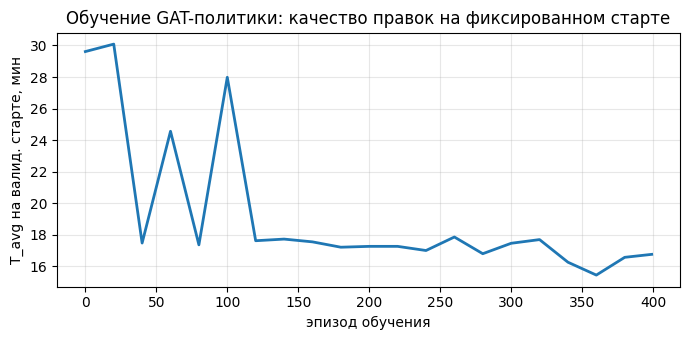

In [19]:
def train(policy):
    opt=torch.optim.Adam(policy.parameters(), lr=RL['lr']); base=0.0
    rng=np.random.default_rng(RL['seed']); val_rng=np.random.default_rng(42); val_start=random_start(val_rng)
    curve=[]
    for ep in range(RL['episodes']):
        routes=random_start(rng); X,T=node_features(routes); logps=[]; rews=[]
        for _ in range(RL['horizon']):
            cands=enumerate_cands(routes)
            if not cands: break
            sc=policy.score_cands(policy.embed(X),cands); dist=torch.distributions.Categorical(F.softmax(sc,0))
            a=dist.sample(); logps.append(dist.log_prob(a)); routes=apply_edit(routes,cands[a.item()])
            X,T2=node_features(routes); rews.append(float(np.clip((T-T2)/60.0,-5,5))); T=T2
        R=0; rets=[]
        for r in reversed(rews): R=r+RL['gamma']*R; rets.insert(0,R)
        rets=torch.tensor(rets,dtype=torch.float32); base=0.9*base+0.1*float(rets.mean())
        loss=-(torch.stack(logps)*(rets-base)).sum(); opt.zero_grad(); loss.backward(); opt.step()
        if ep%20==0 or ep==RL['episodes']-1:
            # качество политики на валидационном старте (greedy, без оракула)
            rr=[list(x) for x in val_start]; Xv,Tv=node_features(rr)
            for _ in range(RL['eval_steps']):
                cs=enumerate_cands(rr)
                if not cs: break
                with torch.no_grad(): c=cs[int(torch.argmax(policy.score_cands(policy.embed(Xv),cs)))]
                rr=apply_edit(rr,c); Xv,Tv=node_features(rr)
            curve.append((ep,Tv/60))
            if ep%80==0 or ep==RL['episodes']-1: print(f"  эпизод {ep:3d} | T_avg политики на валид.старте = {Tv/60:.2f} мин")
    return curve

import time; t0=time.time(); policy=Policy(6); curve=train(policy)
print(f"Обучение заняло {time.time()-t0:.0f} c")
import matplotlib.pyplot as plt
ep_,tv_=zip(*curve)
plt.figure(figsize=(7,3.5)); plt.plot(ep_,tv_,lw=2)
plt.xlabel('эпизод обучения'); plt.ylabel('T_avg на валид. старте, мин')
plt.title('Обучение GAT-политики: качество правок на фиксированном старте'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 10. Оценка на отложенных стартах: политика vs случайные правки
На 8 **новых** случайных сетях применяем правки **без оракула** (политика/случайно — каждый шаг
применяется вслепую, без проверки «стало ли лучше»). Если политика выучила структуру, её
траектория `T_avg` падает, а случайные правки — нет. Считаем также, сколько остановок **вне
исходного пула** политика приводит в сеть (выход за пространство k-кратчайших путей).

C:\Users\georg\AppData\Local\Temp\ipykernel_29016\991676900.py:39: RuntimeWarning: All-NaN slice encountered
  served=np.isfinite(U); shift=np.nanmin(np.where(served,U,np.nan),axis=1,keepdims=True)
C:\Users\georg\AppData\Local\Temp\ipykernel_29016\991676900.py:41: RuntimeWarning: invalid value encountered in divide
  prob=np.where(Z>0,ex/Z,0.0); has=(Z[:,0]>0); demand=POP*P['commuter_share']; stop_in=np.zeros(nstops)


,старт,политика_финал,политика_лучший,случайно_финал,случайно_лучший,остановок_вне_пула
0,19.16,15.90,15.67,22.79,17.45,4
1,17.93,17.29,17.05,19.15,17.13,4
2,34.87,24.62,24.25,33.08,32.87,5
3,34.78,24.00,23.67,35.72,34.31,4
4,30.54,20.72,20.72,27.77,27.08,4
5,16.45,16.26,16.09,19.62,16.45,4
6,17.73,15.75,15.53,16.76,16.33,3
7,31.81,21.62,21.54,26.97,26.85,2


Среднее: старт 25.41 | политика 19.52 | случайно 25.23 мин
Политика приводит в сеть в среднем 3.8 остановок ВНЕ исходного пула


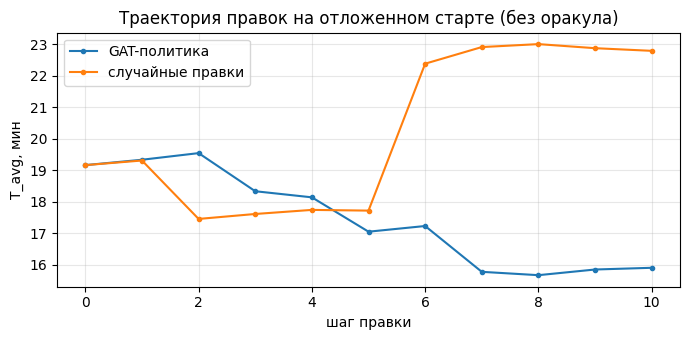

In [20]:
def rollout(policy, routes, mode='policy'):
    routes=[list(r) for r in routes]; X,T=node_features(routes); best=T; rng=np.random.default_rng(7); traj=[T/60]
    for _ in range(RL['eval_steps']):
        cands=enumerate_cands(routes)
        if not cands: break
        if mode=='random': c=cands[rng.integers(len(cands))]
        else:
            with torch.no_grad(): c=cands[int(torch.argmax(policy.score_cands(policy.embed(X),cands)))]
        routes=apply_edit(routes,c); X,T=node_features(routes); best=min(best,T); traj.append(T/60)
    return T/60, best/60, routes, traj

pool_stops=set(s for r in pool for s in r); rng=np.random.default_rng(999); rows=[]; traj_pol=traj_rnd=None
for k in range(RL['eval_starts']):
    st=random_start(rng); T0,_=evaluate_sue2(st)
    pf,pb,rp,tp=rollout(policy,st,'policy'); rf,rb,_,tr=rollout(policy,st,'random')
    esc=len(set(s for r in rp for s in r)-pool_stops)
    rows.append(dict(старт=round(T0/60,2), политика_финал=round(pf,2), политика_лучший=round(pb,2),
                     случайно_финал=round(rf,2), случайно_лучший=round(rb,2), остановок_вне_пула=esc))
    if k==0: traj_pol,traj_rnd=tp,tr
import pandas as pd
res=pd.DataFrame(rows); display(res)
print(f"Среднее: старт {res['старт'].mean():.2f} | политика {res['политика_финал'].mean():.2f} | "
      f"случайно {res['случайно_финал'].mean():.2f} мин")
print(f"Политика приводит в сеть в среднем {res['остановок_вне_пула'].mean():.1f} остановок ВНЕ исходного пула")
plt.figure(figsize=(7,3.5))
plt.plot(traj_pol,'-o',ms=3,label='GAT-политика'); plt.plot(traj_rnd,'-o',ms=3,label='случайные правки')
plt.xlabel('шаг правки'); plt.ylabel('T_avg, мин'); plt.title('Траектория правок на отложенном старте (без оракула)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 11. Применение к опорной SUE-сети и экспорт
Прогоняем обученную политику от опорной (жадной под SUE) сети, принимая только улучшения
(жадный локальный поиск, ведомый политикой), и экспортируем результат в GeoPackage.

In [21]:
def policy_local_search(policy, routes, steps=15):
    routes=[list(r) for r in routes]; X,T=node_features(routes); best=routes; bestT=T
    for _ in range(steps):
        cands=enumerate_cands(routes)
        if not cands: break
        with torch.no_grad():
            order=torch.argsort(policy.score_cands(policy.embed(X),cands),descending=True)
        improved=False
        for idx in order[:10]:                       # пробуем топ-10 предложений политики
            cand=apply_edit(routes,cands[int(idx)]); Tc,_=evaluate_sue2(cand)
            if Tc<bestT-1e-6: routes=cand; bestT=Tc; best=cand; improved=True; break
        X,T=node_features(routes)
        if not improved: break
    return best,bestT
imp_routes, impT = policy_local_search(policy, ref_routes)
print(f"Опорная SUE-сеть: {ref_T/60:.2f} мин -> после правок политики: {impT/60:.2f} мин "
      f"({(ref_T-impT)/ref_T*100:+.1f}%)")
esc=sorted(set(s for r in imp_routes for s in r)-pool_stops)
print(f"Остановок вне исходного пула в итоговой сети: {len(esc)} {esc}")

def route_polyline(route):
    node_seq=[board_nodes[s] for s in route]+[metro_nodes[0]]; coords=[]
    for a,b in zip(node_seq[:-1],node_seq[1:]):
        try: path=nx.shortest_path(G,a,b,weight='time')
        except nx.NetworkXNoPath: continue
        coords+= path if not coords else path[1:]
    return LineString(coords) if len(coords)>=2 else None
gdf=gpd.GeoDataFrame([dict(route_id=i+1,n_stops=len(r),geometry=route_polyline(r))
                      for i,r in enumerate(imp_routes) if route_polyline(r)], crs=CRS)
gdf.to_file(PATHS['out'], layer='routes', driver='GPKG')
print("Сохранено", PATHS['out'], "—", len(gdf), "маршрутов")

Опорная SUE-сеть: 14.06 мин -> после правок политики: 14.06 мин (+0.0%)
Остановок вне исходного пула в итоговой сети: 0 []
Сохранено C:\Users\georg\NIS\Curse_work_2026\gat_routes_v2.gpkg — 8 маршрутов


## 12. Визуализация итоговой сети

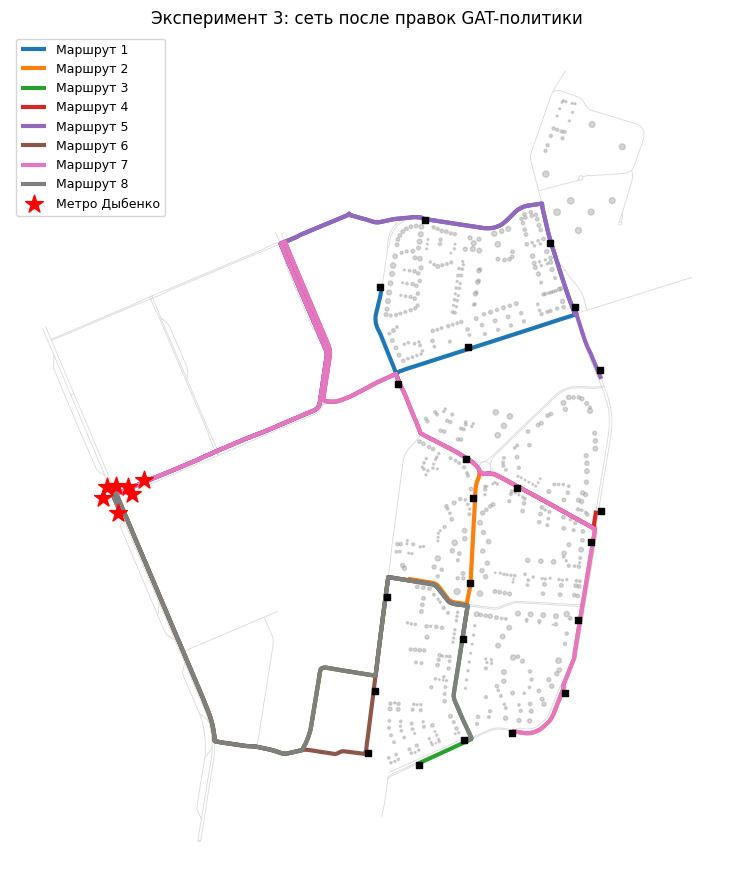

In [22]:
roads=gpd.read_file(PATHS['roads'],layer='doroga_for_busiki').to_crs(CRS)
served_idx=sorted(set(s for r in imp_routes for s in r))
fig,ax=plt.subplots(figsize=(11,9)); roads.plot(ax=ax,color='0.85',lw=0.6,zorder=1)
ent.plot(ax=ax,color='0.6',markersize=ent['population']/30,alpha=0.4,zorder=2)
cmap=plt.cm.tab10
for i,(_,r) in enumerate(gdf.iterrows()):
    gpd.GeoSeries([r.geometry],crs=CRS).plot(ax=ax,color=cmap(i%10),lw=3,zorder=4,label=f"Маршрут {r['route_id']}")
board.iloc[served_idx].plot(ax=ax,color='black',markersize=22,marker='s',zorder=5)
# выделим остановки вне исходного пула
if esc: board.iloc[esc].plot(ax=ax,color='magenta',markersize=70,marker='P',zorder=6,label='вне исходного пула')
metro.plot(ax=ax,color='red',markersize=180,marker='*',zorder=7,label='Метро Дыбенко')
ax.legend(loc='upper left',fontsize=9); ax.set_title('Эксперимент 3: сеть после правок GAT-политики')
ax.set_axis_off(); plt.tight_layout(); plt.show()

## 13. Что показывает эксперимент (для выводов курсовой)
- **GNN-политика обобщает.** Обученная на случайных сетях, она улучшает **отложенные** сети,
  которых не видела — снижает `T_avg` существенно сильнее, чем случайные правки (это контроль
  «учится ли модель чему-то, а не просто двигает остановки наугад»).
- **Выход за пределы пула.** Политика приводит в сеть остановки, которых **не было ни в одном
  из 39 маршрутов-кандидатов** — снимается давнее ограничение всех прошлых методов (поиск только
  внутри пула k-кратчайших путей).
- **Старые «штуки» работают как вход.** Признаки узлов — это выходы SUE-симулятора (`C_s`,
  поток), то есть лестница экспериментов накапливается: GA → SUE → GNN поверх SUE.

### Ограничения (честно)
- Один город (Кудрово), один граф. Обобщение проверено на отложенных **стартовых сетях** того
  же графа, но не на других городах — для этого нужна индуктивная постановка (GraphSAGE-стиль) и
  данные нескольких агломераций. Это естественное направление под тему работы.
- REINFORCE шумен; результат стоит усреднять по нескольким seed (как делали для ГА).
- Действия ограничены `knn` соседями и одной правкой за шаг; интеграция политики как оператора
  мутации **внутрь ГА** (схема Holliday–Dudek) — следующий шаг (стадия B).
- Провозимость выключена (`crowd=False`), как и в эксперименте 3.


## Дополнительные метрики

In [23]:
# === Дополнительные метрики (медиана/P90/minimax/"пешком быстрее"), как в бейзлайне ===
import os

def evaluate_sue2_detailed(routes):
    """Копия evaluate_sue2, но дополнительно возвращает et (T_i по подъездам, сек) и served_pct."""
    K=len(routes); pr=precompute_route_times(routes); stop_routes=defaultdict(list)
    for rid,d in enumerate(pr):
        for s,t in d.items(): stop_routes[s].append((rid,t))
    cyc=np.array([2*route_oneway_time(r)*P['layover_factor'] for r in routes]); seats_avg=sum(FLEET)/len(FLEET)
    Nveh=np.maximum(1,np.full(K,len(FLEET)//K))
    while Nveh.sum()>len(FLEET): Nveh[np.argmax(Nveh)]-=1
    while Nveh.sum()<len(FLEET): Nveh[np.argmin(Nveh)]+=1
    flow=np.zeros(K); prob=has=U=served=None
    for it in range(1,SUE['msa_iters']+1):
        headway=cyc/np.maximum(Nveh,1); freq=1.0/headway; stop_cost=np.full(nstops,np.inf); board_split={}
        for s,lst in stop_routes.items():
            items=sorted([(t,rid) for rid,t in lst]); f=ft=0.0; bestC=np.inf; chosen=[]
            for teff,rid in items:
                f2=f+freq[rid]; ft2=ft+freq[rid]*teff; C=(SUE['w0']+ft2)/f2
                if C<=bestC+1e-9: bestC=C; f=f2; ft=ft2; chosen.append(rid)
                else: break
            stop_cost[s]=bestC; fs=sum(freq[r] for r in chosen); board_split[s]={r:freq[r]/fs for r in chosen}
        U=np.full((E,3),np.inf)
        for c in range(3): U[:,c]=TWALK[:,c]+stop_cost[B_IDX[:,c]]
        served=np.isfinite(U); shift=np.nanmin(np.where(served,U,np.nan),axis=1,keepdims=True)
        ex=np.where(served,np.exp(-SUE['theta']*(U-shift)),0.0); Z=ex.sum(axis=1,keepdims=True)
        prob=np.where(Z>0,ex/Z,0.0); has=(Z[:,0]>0); demand=POP*P['commuter_share']; stop_in=np.zeros(nstops)
        for c in range(3): np.add.at(stop_in,B_IDX[:,c],demand*prob[:,c])
        aux=np.zeros(K)
        for s,split in board_split.items():
            for r,p in split.items(): aux[r]+=stop_in[s]*p
        step=1.0/it; new=flow+step*(aux-flow); gap=np.sum(np.abs(new-flow))/max(np.sum(new),1); flow=new
        w=np.sqrt(np.maximum(flow/P['peak_hours'],1)); Nveh=np.maximum(1,np.round(w/w.sum()*len(FLEET)).astype(int))
        while Nveh.sum()>len(FLEET): Nveh[np.argmax(Nveh)]-=1
        while Nveh.sum()<len(FLEET): Nveh[np.argmax(flow)]+=1
        if gap<SUE['msa_tol'] and it>5: break
    et=np.where(has,(prob*np.where(served,U,0)).sum(axis=1),P['unserved_penalty_s'])
    Tavg=float((POP*et).sum()/POP.sum())
    return Tavg, et, float(POP[has].sum()/POP.sum()*100)


def weighted_percentile(values, weights, q):
    order = np.argsort(values)
    v, w = values[order], weights[order]
    cw = np.cumsum(w); cw /= cw[-1]
    return float(np.interp(q/100, cw, v))


PODYEZD_DIST_PATH = r"C:\Users\georg\NIS\Curse_work_2026\podyezd_dist_to_metro.csv"  # поправьте при необходимости

def extra_metrics(name, routes):
    Tavg, et, served_pct = evaluate_sue2_detailed(routes)
    median_t = weighted_percentile(et, POP, 50)
    p90_t    = weighted_percentile(et, POP, 90)
    served = et < P['unserved_penalty_s']
    minimax_all    = et.max()
    minimax_served = et[served].max() if served.any() else np.nan

    print(f"--- {name} ---")
    print(f"T_avg = {Tavg/60:.2f} мин | обслужено {served_pct:.1f}%")
    metrics = pd.DataFrame([
        dict(Метрика='T_avg (среднее)',       Значение_мин=round(Tavg/60, 2)),
        dict(Метрика='Медиана',               Значение_мин=round(median_t/60, 2)),
        dict(Метрика='P90',                   Значение_мин=round(p90_t/60, 2)),
        dict(Метрика='Minimax (все)',         Значение_мин=round(minimax_all/60, 2)),
        dict(Метрика='Minimax (обслуженные)', Значение_мин=round(minimax_served/60, 2)),
    ])
    display(metrics)

    if os.path.exists(PODYEZD_DIST_PATH):
        walk_df = pd.read_csv(PODYEZD_DIST_PATH)
        id_col   = next((c for c in walk_df.columns if c.lower() in ('entrance_id','id','fid','podyezd','podyezd_id')), walk_df.columns[0])
        dist_col = next((c for c in walk_df.columns if 'dist' in c.lower()), walk_df.columns[1])
        walk_df = walk_df[[id_col, dist_col]].rename(columns={id_col:'entrance_id', dist_col:'dist_m'})
        walk_df['t_walk_direct_s'] = walk_df['dist_m'] / P['walk_speed_mps']

        cmp_df = pd.DataFrame({'entrance_id': EIDS, 'population': POP, 't_bus_s': et})
        cmp_df = cmp_df.merge(walk_df[['entrance_id','t_walk_direct_s']], on='entrance_id', how='left').dropna(subset=['t_walk_direct_s'])

        walk_faster = cmp_df['t_walk_direct_s'] < cmp_df['t_bus_s']
        pct_pop = cmp_df.loc[walk_faster,'population'].sum() / cmp_df['population'].sum() * 100
        print(f"Подъездов, где пешком быстрее: {walk_faster.sum()} / {len(cmp_df)} ({pct_pop:.1f}% населения)")
    else:
        print(f"[пропущено: не найден {PODYEZD_DIST_PATH}]")
    print()
    return metrics

extra_metrics("Опорная SUE-сеть (ref_routes)", ref_routes)
extra_metrics("После правок GAT-политики (imp_routes)", imp_routes)

--- Опорная SUE-сеть (ref_routes) ---
T_avg = 14.06 мин | обслужено 100.0%


,Метрика,Значение_мин
0,T_avg (среднее),14.06
1,Медиана,13.87
2,P90,18.31
3,Minimax (все),21.83
4,Minimax (обслуженные),21.83


Подъездов, где пешком быстрее: 0 / 620 (0.0% населения)

--- После правок GAT-политики (imp_routes) ---
T_avg = 14.06 мин | обслужено 100.0%


,Метрика,Значение_мин
0,T_avg (среднее),14.06
1,Медиана,13.87
2,P90,18.31
3,Minimax (все),21.83
4,Minimax (обслуженные),21.83


Подъездов, где пешком быстрее: 0 / 620 (0.0% населения)



,Метрика,Значение_мин
0,T_avg (среднее),14.06
1,Медиана,13.87
2,P90,18.31
3,Minimax (все),21.83
4,Minimax (обслуженные),21.83
